# Lecture 2 Computation: Optimization

**Constant Elasticity Structure: Recursive Methods for Macroeconomics and Finance**

---

This notebook accompanies Chapter 2 (Static Optimization). We solve the same problem five ways,
progressing from brute force to sophisticated numerical methods. Every method produces the same
answer — what changes is speed, accuracy, and generalizability.

### The Running Example

Throughout this notebook we fix:

$$
\max_{x_1, x_2} \; \mathcal{M}(x_1, x_2;\, \omega, \rho)
\quad \text{subject to} \quad
p_1 x_1 + p_2 x_2 = B
$$

with parameters:

| Symbol | Value | Interpretation |
|--------|-------|----------------|
| $\omega$ | 0.6 | weight on good 1 |
| $\rho$ | −0.5 | curvature (substitutes, $\varepsilon = 2/3$) |
| $p_1$ | 1.2 | price of good 1 |
| $p_2$ | 0.8 | price of good 2 |
| $B$ | 1.0 | budget |

The **closed-form solution** from the lecture notes is:
$$
x_i^* = \omega_i \left(\frac{p_i}{P^*}\right)^{-\varepsilon} \cdot \frac{B}{P^*},
\qquad
P^* = \left(\sum_i \omega_i \, p_i^{\,\rho/(\rho-1)}\right)^{(\rho-1)/\rho}
$$

We will verify each method against this formula.

### Roadmap

| Part | Method | Key concept |
|------|--------|-------------|
| 1 | Grid search | Discretization, curse of dimensionality |
| 2 | Bisection | Bracket-and-halve, FOC as root-finding |
| 3 | `Optim.jl` | Gradient-free and gradient-based solvers |
| 4 | `ForwardDiff.jl` | Automatic differentiation |
| 5 | `NLsolve.jl` | Solving FOC systems directly |

---
## Setup

In [2]:
# Install packages the first time (comment out after first run)
# using Pkg
# Pkg.add(["Plots", "Optim", "ForwardDiff", "NLsolve", "Roots", "LaTeXStrings", "Printf"])

In [3]:
using Plots

using Printf
using LinearAlgebra

# ── Global parameters (the running example) ──────────────────────────────────
const ω  = 0.6      # weight on good 1
const ρ  = -0.5     # curvature parameter
const p₁ = 1.2      # price of good 1
const p₂ = 0.8      # price of good 2
const B  = 1.0      # budget

# Derived parameter
const ε  = 1 / (1 - ρ)   # elasticity of substitution

@printf "Parameters: ω = %.1f | ρ = %.2f | ε = %.4f | p = (%.1f, %.1f) | B = %.1f\n" ω ρ ε p₁ p₂ B

Parameters: ω = 0.6 | ρ = -0.50 | ε = 0.6667 | p = (1.2, 0.8) | B = 1.0


In [4]:
# ── Core functions ────────────────────────────────────────────────────────────

"""
    canonical_mean(x₁, x₂, ω, ρ)

Canonical generalized mean with two goods:
    𝓜 = (ω^(1-ρ) x₁^ρ + (1-ω)^(1-ρ) x₂^ρ)^(1/ρ)
"""
function canonical_mean(x₁, x₂, ω, ρ; tol=1e-10)
    if abs(ρ) < tol
        return x₁^ω * x₂^(1-ω)   # Cobb-Douglas limit
    end
    S = ω^(1-ρ) * x₁^ρ + (1-ω)^(1-ρ) * x₂^ρ
    return S^(1/ρ)
end

"""
    price_index(p₁, p₂, ω, ρ)

CES price index:
    P* = (ω p₁^(ρ̃) + (1-ω) p₂^(ρ̃))^(1/ρ̃),   ρ̃ = ρ/(ρ-1)
"""
function price_index(p₁, p₂, ω, ρ)
    ρ̃ = ρ / (ρ - 1)   # power of price index = 1 - ε
    S = ω * p₁^ρ̃ + (1-ω) * p₂^ρ̃
    return S^(1/ρ̃)
end

"""
    closed_form(p₁, p₂, ω, ρ, B)

Closed-form optimal quantities from the lecture notes.
Returns (x₁*, x₂*, P*, 𝓜*)
"""
function closed_form(p₁, p₂, ω, ρ, B)
    ε  = 1 / (1 - ρ)
    Ps = price_index(p₁, p₂, ω, ρ)
    x₁ = ω * (p₁/Ps)^(-ε) * (B/Ps)
    x₂ = (1-ω) * (p₂/Ps)^(-ε) * (B/Ps)
    M  = B / Ps
    return x₁, x₂, Ps, M
end

# ── Compute and display the benchmark ────────────────────────────────────────
x₁_cf, x₂_cf, Pstar_cf, M_cf = closed_form(p₁, p₂, ω, ρ, B)

println("\n── Closed-Form Benchmark ──────────────────────")
@printf "  Price index  P*  = %.6f\n" Pstar_cf
@printf "  Optimal  x₁*     = %.6f\n" x₁_cf
@printf "  Optimal  x₂*     = %.6f\n" x₂_cf
@printf "  Value    𝓜*     = %.6f\n" M_cf
@printf "  Budget check     = %.6f  (should be %.1f)\n" (p₁*x₁_cf + p₂*x₂_cf) B


── Closed-Form Benchmark ──────────────────────
  Price index  P*  = 1.027006
  Optimal  x₁*     = 0.526631
  Optimal  x₂*     = 0.460054
  Value    𝓜*     = 0.973704
  Budget check     = 1.000000  (should be 1.0)


---
## Part 1 — Grid Search

The simplest strategy: evaluate the objective on a finite grid and find the maximum.

### Idea

The constraint $p_1 x_1 + p_2 x_2 = B$ defines a line in $(x_1, x_2)$ space. Any point on
this line can be parametrized by $x_1 \in [0,\, B/p_1]$, with $x_2 = (B - p_1 x_1)/p_2$.
So we:

1. Build a grid of $G$ points for $x_1$.
2. Recover $x_2$ from the constraint exactly (no feasibility tolerance needed).
3. Evaluate $\mathcal{M}(x_1, x_2)$ at each point.
4. Report the maximum.

This reduces the constrained 2D problem to a 1D grid search — a useful trick that
foreshadows the substitution we will use in Part 2.

In [5]:
# ── 1.1  Grid search along the budget line ───────────────────────────────────

G = 1_000   # number of grid points

# x₁ ranges from 0 to B/p₁ (endpoints excluded: we need x₁ > 0 and x₂ > 0)
x₁_grid = LinRange(1e-6, B/p₁ - 1e-6, G)

# Recover x₂ from the constraint exactly
x₂_grid = @. (B - p₁ * x₁_grid) / p₂

# Evaluate the objective at each point
M_grid = @. canonical_mean(x₁_grid, x₂_grid, ω, ρ)

# Find the maximum
idx_max   = argmax(M_grid)
x₁_gs     = x₁_grid[idx_max]
x₂_gs     = x₂_grid[idx_max]
M_gs      = M_grid[idx_max]

println("── Grid Search (G = $G) ──────────────────────")
@printf "  Optimal  x₁*    = %.6f   (error: %+.2e)\n" x₁_gs  (x₁_gs - x₁_cf)
@printf "  Optimal  x₂*    = %.6f   (error: %+.2e)\n" x₂_gs  (x₂_gs - x₂_cf)
@printf "  Value    𝓜*    = %.6f   (error: %+.2e)\n" M_gs   (M_gs  - M_cf)

── Grid Search (G = 1000) ──────────────────────
  Optimal  x₁*    = 0.526359   (error: -2.71e-04)
  Optimal  x₂*    = 0.460461   (error: +4.07e-04)
  Value    𝓜*    = 0.973704   (error: -3.32e-07)


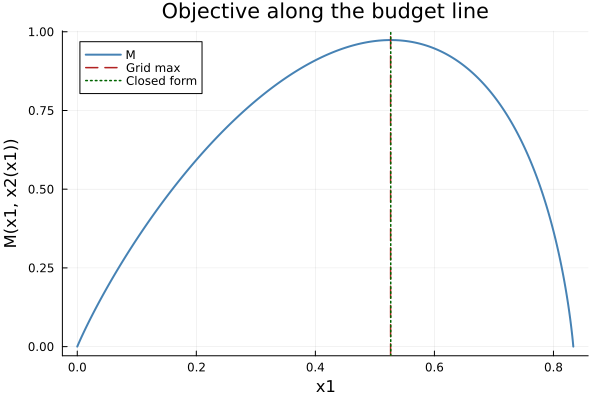

In [6]:
# ── 1.2  Visualize the objective along the budget line ───────────────────────

p1 = plot(
    x₁_grid, M_grid,
    xlabel = "x1",
    ylabel = "M(x1, x2(x1))",
    title  = "Objective along the budget line",
    label  = "M",
    lw = 2, color = :steelblue
)
vline!([x₁_gs],  label = "Grid max",   color = :firebrick,  lw = 1.5, ls = :dash)
vline!([x₁_cf],  label = "Closed form", color = :darkgreen, lw = 1.5, ls = :dot)
display(p1)

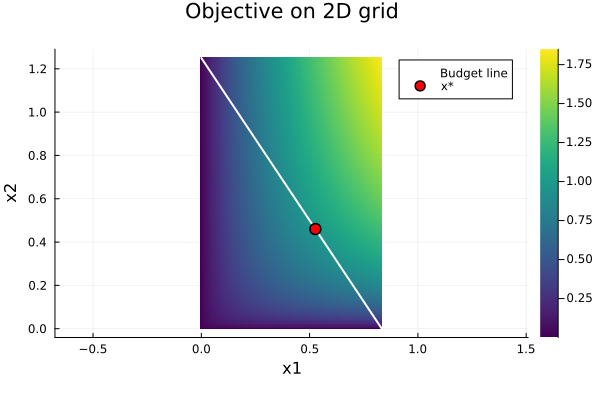

In [7]:
# ── 1.3  Visualize the objective on the 2D grid ──────────────────────────────
#
# Now we evaluate on a full 2D grid (ignoring the constraint) and overlay
# the budget line. This shows why grid search in 2D is more expensive.

G2 = 200
x₁_2d = LinRange(1e-4, B/p₁, G2)
x₂_2d = LinRange(1e-4, B/p₂, G2)

# Evaluate on the full grid — note the broadcasting over rows and columns
M_2d = [canonical_mean(a, b, ω, ρ) for b in x₂_2d, a in x₁_2d]

p2 = heatmap(
    x₁_2d, x₂_2d, M_2d,
    xlabel = "x1", ylabel = "x2",
    title  = "Objective on 2D grid",
    color  = :viridis,
    aspect_ratio = :equal
)

# Overlay the budget line
x₁_line = LinRange(0, B/p₁, 100)
x₂_line = @. (B - p₁ * x₁_line) / p₂
plot!(p2, x₁_line, x₂_line, label = "Budget line", color = :white, lw = 2)

# Mark the optimum
scatter!(p2, [x₁_cf], [x₂_cf], label = "x*", color = :red, ms = 6, msw = 2)

display(p2)

In [8]:
# ── 1.4  The curse of dimensionality ─────────────────────────────────────────
#
# Grid search requires G^n evaluations for n goods and G points per dimension.
# We show how the cost explodes with dimension.

# Helper: format large integers with commas
function format_with_commas(n::Int)
    s = string(n)
    result = ""
    for (i, c) in enumerate(reverse(s))
        if i > 1 && (i - 1) % 3 == 0
            result = "," * result
        end
        result = c * result
    end
    return result
end

println("── Grid evaluations by dimension (G = 200 per axis) ──")
println("  n goods   |   G^n evaluations")
println("  ----------|---------------------")
G_demo = 200
for n in 1:8
    evals = G_demo^n
    @printf "     %d      |   %s\n" n format_with_commas(evals)
end

println("\nConclusion: grid search is infeasible beyond 3-4 dimensions.")


── Grid evaluations by dimension (G = 200 per axis) ──
  n goods   |   G^n evaluations
  ----------|---------------------
     1      |   200
     2      |   40,000
     3      |   8,000,000
     4      |   1,600,000,000
     5      |   320,000,000,000
     6      |   64,000,000,000,000
     7      |   12,800,000,000,000,000
     8      |   2,560,000,000,000,000,000

Conclusion: grid search is infeasible beyond 3-4 dimensions.


In [9]:
# ── 1.5  Effect of grid resolution on accuracy ───────────────────────────────

println("── Grid resolution vs. accuracy ─────────────────────────────")
println("  G (points)  |  x₁* error    |  𝓜* error    |  Time (ms)")
println("  ------------|---------------|---------------|------------")

for G_test in [10, 50, 100, 500, 1_000, 5_000, 10_000]
    grid  = LinRange(1e-6, B/p₁ - 1e-6, G_test)
    x2g   = @. (B - p₁ * grid) / p₂
    t     = @elapsed Mg = @. canonical_mean(grid, x2g, ω, ρ)
    idx   = argmax(Mg)
    err_x = abs(grid[idx] - x₁_cf)
    err_M = abs(Mg[idx]   - M_cf)
    @printf "  %10d  |  %+.4e  |  %+.4e  |  %.2f\n" G_test err_x err_M (t*1000)
end

── Grid resolution vs. accuracy ─────────────────────────────
  G (points)  |  x₁* error    |  𝓜* error    |  Time (ms)
  ------------|---------------|---------------|------------
          10  |  +2.8925e-02  |  +3.9149e-03  |  0.00
          50  |  +5.8006e-04  |  +1.5223e-06  |  0.00
         100  |  +3.6722e-03  |  +6.1226e-05  |  0.00
         500  |  +5.7871e-04  |  +1.5132e-06  |  0.02
        1000  |  +2.7113e-04  |  +3.3226e-07  |  0.04
        5000  |  +2.5499e-05  |  +2.9396e-09  |  0.17
       10000  |  +5.1769e-06  |  +1.2118e-10  |  0.43


### Takeaway from Part 1

Grid search is transparent and always works, but:

- **Accuracy scales as $O(1/G)$** — to gain one decimal place, multiply $G$ by 10.
- **Cost scales as $O(G^n)$** — adding one good multiplies the cost by $G$.

For a 2-good problem with $G = 10{,}000$ we already need $10^8$ evaluations in the full 2D case.
For $n = 10$ goods it is hopeless.

The fundamental lesson: we need methods that **exploit the structure of the problem**,
not just sample from it.

---
## Part 2 — Bisection

Bisection exploits one piece of structure: the objective is **unimodal** on the budget line,
so its derivative changes sign exactly once. We can find that zero by bracket-and-halve.

### From the FOC to a root-finding problem

The first-order condition from the lecture notes (equating MRS to the price ratio) is:

$$
\frac{\omega^{1-\rho}\, x_1^{\rho-1}}{(1-\omega)^{1-\rho}\, x_2^{\rho-1}} = \frac{p_1}{p_2}
$$

Substituting $x_2 = (B - p_1 x_1)/p_2$, this becomes a single equation in $x_1$. Define:

$$
g(x_1) \;\equiv\; \frac{\omega^{1-\rho}\, x_1^{\rho-1}}{(1-\omega)^{1-\rho}\, x_2(x_1)^{\rho-1}} - \frac{p_1}{p_2}
$$

We need to find $x_1^*$ such that $g(x_1^*) = 0$.

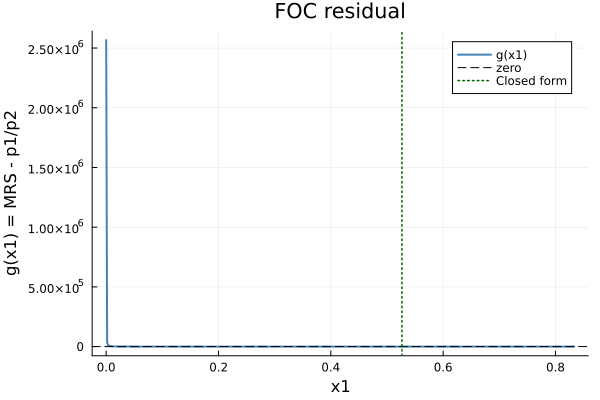


g(0.0001) = +2566985.8613
g(0.8332) = -1.5000
Sign change: true


In [10]:
# ── 2.1  Define the excess-MRS function g ────────────────────────────────────

"""
    excess_mrs(x₁, ω, ρ, p₁, p₂, B)

FOC residual: MRS minus price ratio.
Root of this function is the optimal x₁.
"""
function excess_mrs(x₁, ω, ρ, p₁, p₂, B)
    x₂  = (B - p₁ * x₁) / p₂
    MRS = (ω^(1-ρ) * x₁^(ρ-1)) / ((1-ω)^(1-ρ) * x₂^(ρ-1))
    return MRS - p₁/p₂
end

# Plot g(x₁) on the feasible range
x₁_plot = LinRange(1e-4, B/p₁ - 1e-4, 500)
g_plot   = [excess_mrs(x, ω, ρ, p₁, p₂, B) for x in x₁_plot]

p3 = plot(
    x₁_plot, g_plot,
    xlabel = "x1",
    ylabel = "g(x1) = MRS - p1/p2",
    title  = "FOC residual",
    label  = "g(x1)",
    lw = 2, color = :steelblue
)
hline!([0.0],   label = "zero",        color = :black,    lw = 1, ls = :dash)
vline!([x₁_cf], label = "Closed form", color = :darkgreen, lw = 1.5, ls = :dot)
display(p3)

# Verify the bracket: g must change sign
a, b = 1e-4, B/p₁ - 1e-4
@printf "\ng(%.4f) = %+.4f\n" a excess_mrs(a, ω, ρ, p₁, p₂, B)
@printf "g(%.4f) = %+.4f\n" b excess_mrs(b, ω, ρ, p₁, p₂, B)
println("Sign change: ", sign(excess_mrs(a, ω, ρ, p₁, p₂, B)) != sign(excess_mrs(b, ω, ρ, p₁, p₂, B)))

In [11]:
# ── 2.2  Bisection — implement from scratch ───────────────────────────────────
#
# Algorithm:
#   Given a bracket [a, b] with g(a) < 0 < g(b):
#     1. m ← (a + b) / 2
#     2. If g(m) > 0, replace b ← m; else replace a ← m
#     3. Repeat until b - a < tol
#
# The interval halves each iteration: after k steps, error ≤ (b-a)/2^k.

"""
    bisection(f, a, b; tol=1e-10, maxiter=200, verbose=false)

Find a root of f in [a, b] by bisection.
Assumes f(a) and f(b) have opposite signs.
"""
function bisection(f, a, b; tol=1e-10, maxiter=200, verbose=false)
    fa, fb = f(a), f(b)
    @assert fa * fb < 0  "f(a) and f(b) must have opposite signs"

    history = Float64[]   # track midpoints to visualize convergence

    for k in 1:maxiter
        m  = (a + b) / 2
        fm = f(m)
        push!(history, m)

        if verbose
            @printf "  iter %3d:  a = %.8f  b = %.8f  m = %.8f  f(m) = %+.4e\n" k a b m fm
        end

        if abs(fm) < tol || (b - a) / 2 < tol
            return m, k, history
        end

        if fa * fm < 0   # root is in [a, m]
            b, fb = m, fm
        else             # root is in [m, b]
            a, fa = m, fm
        end
    end

    error("Bisection did not converge in $maxiter iterations")
end

# ── Run with verbose output ───────────────────────────────────────────────────
g(x) = excess_mrs(x, ω, ρ, p₁, p₂, B)

println("── Bisection iterations ─────────────────────────────────────")
x₁_bis, k_bis, history_bis = bisection(g, 1e-4, B/p₁ - 1e-4; tol=1e-10, verbose=true)
x₂_bis = (B - p₁ * x₁_bis) / p₂
M_bis  = canonical_mean(x₁_bis, x₂_bis, ω, ρ)

println("\n── Bisection Result ─────────────────────────────────────────")
@printf "  Converged in %d iterations\n" k_bis
@printf "  Optimal  x₁*    = %.10f   (error: %+.2e)\n" x₁_bis (x₁_bis - x₁_cf)
@printf "  Optimal  x₂*    = %.10f   (error: %+.2e)\n" x₂_bis (x₂_bis - x₂_cf)
@printf "  Value    𝓜*     = %.10f   (error: %+.2e)\n" M_bis  (M_bis  - M_cf)

── Bisection iterations ─────────────────────────────────────
  iter   1:  a = 0.00010000  b = 0.83323333  m = 0.41666667  f(m) = +1.8750e+00
  iter   2:  a = 0.41666667  b = 0.83323333  m = 0.62495000  f(m) = -8.5017e-01
  iter   3:  a = 0.41666667  b = 0.62495000  m = 0.52080833  f(m) = +6.8859e-02
  iter   4:  a = 0.52080833  b = 0.62495000  m = 0.57287917  f(m) = -4.6539e-01
  iter   5:  a = 0.52080833  b = 0.57287917  m = 0.54684375  f(m) = -2.2020e-01
  iter   6:  a = 0.52080833  b = 0.54684375  m = 0.53382604  f(m) = -8.1644e-02
  iter   7:  a = 0.52080833  b = 0.53382604  m = 0.52731719  f(m) = -7.9534e-03
  iter   8:  a = 0.52080833  b = 0.52731719  m = 0.52406276  f(m) = +3.0054e-02
  iter   9:  a = 0.52406276  b = 0.52731719  m = 0.52568997  f(m) = +1.0952e-02
  iter  10:  a = 0.52568997  b = 0.52731719  m = 0.52650358  f(m) = +1.4746e-03
  iter  11:  a = 0.52650358  b = 0.52731719  m = 0.52691038  f(m) = -3.2455e-03
  iter  12:  a = 0.52650358  b = 0.52691038  m = 0.5267069

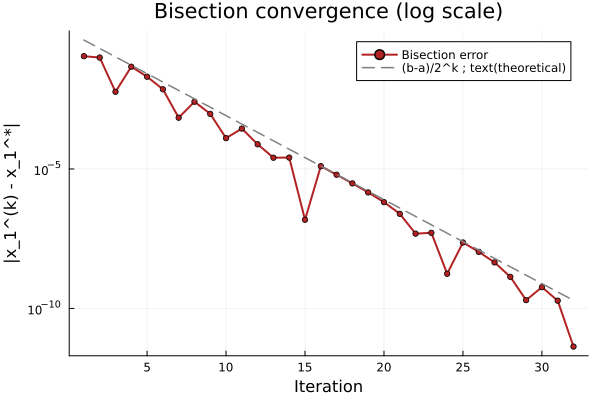

In [12]:
# ── 2.3  Visualize convergence ────────────────────────────────────────────────
#
# Each bisection step halves the error. On a log scale, convergence is linear.

errors_bis = abs.(history_bis .- x₁_cf)

p4 = plot(
    1:length(errors_bis), errors_bis,
    yscale = :log10,
    xlabel = "Iteration",
    ylabel = "|x_1^(k) - x_1^*|",
    title  = "Bisection convergence (log scale)",
    label  = "Bisection error",
    lw = 2, color = :firebrick, marker = :circle, ms = 3
)

# Theoretical rate: error_k = (b-a) / 2^k
initial_bracket = B/p₁ - 2e-4
theoretical = [initial_bracket / 2^k for k in 1:length(errors_bis)]
plot!(p4, 1:length(theoretical), theoretical,
    label = "(b-a)/2^k ; text(theoretical)",
    lw = 1.5, ls = :dash, color = :gray)

display(p4)

In [13]:
# ── 2.4  Using Roots.jl ───────────────────────────────────────────────────────
#
# The standard library version — same algorithm, more options.

using Roots

# Bisection via Roots.jl
x₁_roots = find_zero(g, (1e-4, B/p₁ - 1e-4), Bisection())
x₂_roots = (B - p₁ * x₁_roots) / p₂
M_roots  = canonical_mean(x₁_roots, x₂_roots, ω, ρ)

println("── Roots.jl Bisection ───────────────────────────────────────")
@printf "  Optimal  x₁*    = %.10f   (error: %+.2e)
" x₁_roots (x₁_roots - x₁_cf)
@printf "  Optimal  x₂*    = %.10f   (error: %+.2e)
" x₂_roots (x₂_roots - x₂_cf)
@printf "  Value    𝓜*     = %.10f   (error: %+.2e)
" M_roots  (M_roots  - M_cf)

# AlefeldPotraShi() uses the secant method: combines two function evaluations to
# steps when safe but falls back to bisection to stay within the bracket.
# Pure Order1() (secant) can step outside the feasible region, causing
# x₂ < 0 and a DomainError on fractional powers.
x₁_secant = find_zero(g, (1e-4, B/p₁ - 1e-4), AlefeldPotraShi())
@printf "
  Secant   x₁*    = %.10f   (error: %+.2e)
" x₁_secant (x₁_secant - x₁_cf)


── Roots.jl Bisection ───────────────────────────────────────
  Optimal  x₁*    = 0.5266305561   (error: +0.00e+00)
  Optimal  x₂*    = 0.4600541659   (error: +0.00e+00)
  Value    𝓜*     = 0.9737038857   (error: +0.00e+00)

  Secant   x₁*    = 0.5266305561   (error: +0.00e+00)


In [14]:
# ── 2.5  How many iterations does bisection need? ────────────────────────────
#
# Theory: to achieve tolerance ε on a bracket of width (b-a),
# we need k ≥ log₂((b-a)/ε) iterations.

bracket_width = B/p₁ - 2e-4
println("── Iterations required by bisection ────────────────────────")
println("  Tolerance   |  log₂((b-a)/tol)  |  Actual bisection")
println("  ------------|-------------------|-----------------")
for (tol_exp, tol_label) in [(-4,"1e-4"), (-6,"1e-6"), (-8,"1e-8"), (-10,"1e-10"), (-12,"1e-12")]
    tol_val  = 10.0^tol_exp
    k_theory = ceil(Int, log2(bracket_width / tol_val))
    _, k_actual, _ = bisection(g, 1e-4, B/p₁ - 1e-4; tol=tol_val)
    @printf "  %-12s|  %17d  |  %d\n" tol_label k_theory k_actual
end

── Iterations required by bisection ────────────────────────
  Tolerance   |  log₂((b-a)/tol)  |  Actual bisection
  ------------|-------------------|-----------------
  1e-4        |                 14  |  14
  1e-6        |                 20  |  20
  1e-8        |                 27  |  27
  1e-10       |                 33  |  32
  1e-12       |                 40  |  40


### Takeaway from Part 2

Bisection is a major improvement over grid search:

- **Accuracy**: achieves machine precision ($\sim 10^{-10}$) in about 35 iterations — far fewer than the $10^4$ grid points needed for similar accuracy.
- **Reliability**: guaranteed to converge whenever $g$ is continuous and the bracket is valid — no tuning required.
- **Limitation**: requires a *scalar* equation. It cannot directly handle the $n$-good problem with $n > 1$ free variable.

The key insight: we exploited the structure of the FOC (one equation in one unknown after
substituting the constraint) to convert a 2D constrained problem into a 1D root-finding problem.

---
## Part 3 — Gradient-Free and Gradient-Based Optimization via `Optim.jl`

Now we solve the problem without exploiting the FOC structure manually.
We optimize directly over $x_1$, using the constraint to eliminate $x_2$.

In [15]:
using Optim

# ── 3.1  Objective as a function of x₁ only (constraint substituted in) ──────
function obj(x₁)
    v = x₁[1]
    x₂ = (B - p₁*v) / p₂
    if v ≤ 0 || x₂ ≤ 0
        return Inf  # penalty for infeasible points
    end
    return -canonical_mean(v, x₂, ω, ρ)  # negate: Optim minimizes
end

# ── Nelder-Mead (gradient-free) ───────────────────────────────────────────────
res_nm = optimize(obj, [0.3], NelderMead())

x₁_nm = res_nm.minimizer[1]
x₂_nm = (B - p₁*x₁_nm) / p₂
M_nm  = canonical_mean(x₁_nm, x₂_nm, ω, ρ)

println("── Nelder-Mead ──────────────────────────────────────────────")
@printf "  Converged: %s  |  iterations: %d  |  f-evals: %d
" Optim.converged(res_nm) res_nm.iterations res_nm.f_calls
@printf "  Optimal  x₁*    = %.10f   (error: %+.2e)
" x₁_nm (x₁_nm - x₁_cf)
@printf "  Value    𝓜*     = %.10f   (error: %+.2e)
" M_nm  (M_nm  - M_cf)

# ── BFGS (gradient-based, with box constraints) ──────────────────────────────
lower = [1e-6]
upper = [B/p₁ - 1e-6]
res_bfgs = optimize(obj, lower, upper, [0.3], Fminbox(BFGS()))

x₁_bfgs = res_bfgs.minimizer[1]
x₂_bfgs = (B - p₁*x₁_bfgs) / p₂
M_bfgs  = canonical_mean(x₁_bfgs, x₂_bfgs, ω, ρ)

println("
── BFGS (box-constrained) ───────────────────────────────────")
@printf "  Converged: %s  |  iterations: %d  |  f-evals: %d
" Optim.converged(res_bfgs) res_bfgs.iterations res_bfgs.f_calls
@printf "  Optimal  x₁*    = %.10f   (error: %+.2e)
" x₁_bfgs (x₁_bfgs - x₁_cf)
@printf "  Value    𝓜*     = %.10f   (error: %+.2e)
" M_bfgs  (M_bfgs  - M_cf)


── Nelder-Mead ──────────────────────────────────────────────
  Converged: true  |  iterations: 7  |  f-evals: 17
  Optimal  x₁*    = 0.5266113281   (error: -1.92e-05)
  Value    𝓜*     = 0.9737038840   (error: -1.67e-09)

── BFGS (box-constrained) ───────────────────────────────────
  Converged: true  |  iterations: 3  |  f-evals: 16
  Optimal  x₁*    = 0.5266305560   (error: -6.88e-11)
  Value    𝓜*     = 0.9737038857   (error: +0.00e+00)


In [20]:
# ── Nelder-Mead (gradient-free) ───────────────────────────────────────────────
res_bfgs = optimize(obj, [0.3], BFGS())

x₁_bfgs = res_bfgs.minimizer[1]
x₂_bfgs = (B - p₁*x₁_bfgs) / p₂
M_bfgs  = canonical_mean(x₁_bfgs, x₂_bfgs, ω, ρ)

println("── BFGS ──────────────────────────────────────────────")
@printf "  Converged: %s  |  iterations: %d  |  f-evals: %d
" Optim.converged(res_bfgs) res_bfgs.iterations res_bfgs.f_calls
@printf "  Optimal  x₁*    = %.10f   (error: %+.2e)
" x₁_bfgs (x₁_bfgs - x₁_cf)
@printf "  Value    𝓜*     = %.10f   (error: %+.2e)
" M_bfgs  (M_bfgs  - M_cf)

# ── BFGS (gradient-based, with box constraints) ──────────────────────────────
lower = [1e-6]
upper = [B/p₁ - 1e-6]
res_bfgs = optimize(obj, lower, upper, [0.3], Fminbox(BFGS()))

x₁_bfgs = res_bfgs.minimizer[1]
x₂_bfgs = (B - p₁*x₁_bfgs) / p₂
M_bfgs  = canonical_mean(x₁_bfgs, x₂_bfgs, ω, ρ)

println("
── BFGS (box-constrained) ───────────────────────────────────")
@printf "  Converged: %s  |  iterations: %d  |  f-evals: %d
" Optim.converged(res_bfgs) res_bfgs.iterations res_bfgs.f_calls
@printf "  Optimal  x₁*    = %.10f   (error: %+.2e)
" x₁_bfgs (x₁_bfgs - x₁_cf)
@printf "  Value    𝓜*     = %.10f   (error: %+.2e)
" M_bfgs  (M_bfgs  - M_cf)


── BFGS ──────────────────────────────────────────────
  Converged: true  |  iterations: 4  |  f-evals: 12
  Optimal  x₁*    = 0.5266305560   (error: -1.82e-11)
  Value    𝓜*     = 0.9737038857   (error: +0.00e+00)

── BFGS (box-constrained) ───────────────────────────────────
  Converged: true  |  iterations: 3  |  f-evals: 16
  Optimal  x₁*    = 0.5266305560   (error: -6.88e-11)
  Value    𝓜*     = 0.9737038857   (error: +0.00e+00)


---
## Part 4 — Automatic Differentiation via `ForwardDiff.jl`

The lecture notes (Section 7) state:
$$w_i = \frac{\partial \ln P^*}{\partial \ln p_i}$$

Let us verify this computationally. We define `log_P_star(p)` and ask `ForwardDiff` for its gradient.

In [16]:
using ForwardDiff

# ── 4.1  Gradient of log P* is the budget-share vector ───────────────────────

# Log price index as a function of log-prices (so gradient = share elasticity)
function log_price_index(logp, ω, ρ)
    p₁, p₂ = exp(logp[1]), exp(logp[2])
    return log(price_index(p₁, p₂, ω, ρ))
end

logp₀  = log.([p₁, p₂])
grad   = ForwardDiff.gradient(lp -> log_price_index(lp, ω, ρ), logp₀)

# Closed-form budget shares
w₁_cf  = p₁ * x₁_cf / B
w₂_cf  = p₂ * x₂_cf / B

println("── AD gradient of log P* vs. closed-form budget shares ──────")
@printf "  ∂ ln P*/∂ ln p₁ = %.8f   w₁* = %.8f   error: %+.2e\n" grad[1] w₁_cf (grad[1]-w₁_cf)
@printf "  ∂ ln P*/∂ ln p₂ = %.8f   w₂* = %.8f   error: %+.2e\n" grad[2] w₂_cf (grad[2]-w₂_cf)

── AD gradient of log P* vs. closed-form budget shares ──────
  ∂ ln P*/∂ ln p₁ = 0.63195667   w₁* = 0.63195667   error: +0.00e+00
  ∂ ln P*/∂ ln p₂ = 0.36804333   w₂* = 0.36804333   error: -5.55e-17


In [21]:
# ── 4.2  AD vs. finite differences: accuracy comparison ──────────────────────

f_scalar(lp1) = log_price_index([lp1, log(p₂)], ω, ρ)
true_grad     = ForwardDiff.derivative(f_scalar, log(p₁))

println("── Finite difference error vs. step size h ─────────────────")
println("  h           |  FD gradient   |  Error vs AD")
println("  ------------|----------------|----------------")
for h_exp in -1:-1:-15
    h    = 10.0^h_exp
    fd   = (f_scalar(log(p₁) + h) - f_scalar(log(p₁))) / h
    err  = abs(fd - true_grad)
    @printf "  1e%-3d       |  %.8f    |  %.2e\n" h_exp fd err
end
println("\nAD result: ", true_grad, "  (exact, machine precision)")

── Finite difference error vs. step size h ─────────────────
  h           |  FD gradient   |  Error vs AD
  ------------|----------------|----------------
  1e-1        |  0.63582162    |  3.86e-03
  1e-2        |  0.63234420    |  3.88e-04
  1e-3        |  0.63199543    |  3.88e-05
  1e-4        |  0.63196054    |  3.88e-06
  1e-5        |  0.63195705    |  3.88e-07
  1e-6        |  0.63195671    |  3.97e-08
  1e-7        |  0.63195667    |  8.68e-10
  1e-8        |  0.63195670    |  3.60e-08
  1e-9        |  0.63195671    |  3.84e-08
  1e-10       |  0.63195626    |  4.09e-07
  1e-11       |  0.63199099    |  3.43e-05
  1e-12       |  0.63240038    |  4.44e-04
  1e-13       |  0.63348632    |  1.53e-03
  1e-14       |  0.64843964    |  1.65e-02
  1e-15       |  0.64878658    |  1.68e-02

AD result: 0.6319566672734003  (exact, machine precision)


---
## Part 5 — System of FOCs via `NLsolve.jl`

For the $n$-good case, we cannot reduce to a scalar equation analytically.
We solve the full FOC system:

$$
F(x_1, \ldots, x_n) = \mathbf{0}, \qquad
F_i(\mathbf{x}) = \omega_i^{1-\rho}\, x_i^{\rho-1} - \lambda p_i, \quad \sum_i p_i x_i - B = 0
$$

treating $\lambda$ as an additional unknown.

In [22]:
using NLsolve

# ── 5.1  FOC residual (in-place, Julia convention) ───────────────────────────
#
# Unknowns: z = [x₁, x₂, λ]
# Equations:
#   (1)  𝓜^(1-ρ) ω^(1-ρ) x₁^(ρ-1) - λ p₁ = 0
#   (2)  𝓜^(1-ρ) (1-ω)^(1-ρ) x₂^(ρ-1) - λ p₂ = 0
#   (3)  p₁ x₁ + p₂ x₂ - B = 0
#
# The 𝓜^(1-ρ) term is common and cancels in the ratio (Part 2),
# but here we solve all equations simultaneously.

function foc!(F, z, ω, ρ, p₁, p₂, B)
    x₁, x₂, λ = z[1], z[2], z[3]
    M = canonical_mean(x₁, x₂, ω, ρ)
    F[1] = M^(1-ρ) * ω^(1-ρ)     * x₁^(ρ-1) - λ * p₁
    F[2] = M^(1-ρ) * (1-ω)^(1-ρ) * x₂^(ρ-1) - λ * p₂
    F[3] = p₁*x₁ + p₂*x₂ - B
end

# Initial guess: equal split on budget line
z₀ = [B/(2p₁), B/(2p₂), 1.0]

res_foc = nlsolve(
    (F, z) -> foc!(F, z, ω, ρ, p₁, p₂, B),
    z₀;
    method    = :trust_region,
    ftol      = 1e-12,
    show_trace = false
)

x₁_foc, x₂_foc, λ_foc = res_foc.zero
M_foc = canonical_mean(x₁_foc, x₂_foc, ω, ρ)

println("── NLsolve FOC System ───────────────────────────────────────")
@printf "  Converged: %s\n" res_foc.f_converged
@printf "  Optimal  x₁*    = %.10f   (error: %+.2e)\n" x₁_foc (x₁_foc - x₁_cf)
@printf "  Optimal  x₂*    = %.10f   (error: %+.2e)\n" x₂_foc (x₂_foc - x₂_cf)
@printf "  Lagrange  λ*    = %.10f\n" λ_foc
@printf "  Value    𝓜*     = %.10f   (error: %+.2e)\n" M_foc  (M_foc  - M_cf)

# Verify λ = 𝓜/B (from the lecture notes)
@printf "\n  𝓜*/B = %.10f  vs.  λ* = %.10f  (should match)\n" (M_foc/B) λ_foc

── NLsolve FOC System ───────────────────────────────────────
  Converged: true
  Optimal  x₁*    = 0.5266305561   (error: +1.51e-13)
  Optimal  x₂*    = 0.4600541659   (error: -2.27e-13)
  Lagrange  λ*    = 0.9737038857
  Value    𝓜*     = 0.9737038857   (error: +0.00e+00)

  𝓜*/B = 0.9737038857  vs.  λ* = 0.9737038857  (should match)


---
## Summary and Timing Comparison

In [23]:
# ── Final comparison table ────────────────────────────────────────────────────

println("═" ^ 80)
println("SUMMARY: All methods, same problem")
println("═" ^ 80)
@printf "%-22s  %12s  %12s  %12s  %10s\n" "Method" "x₁*" "x₂*" "𝓜*" "Time (μs)"
println("─" ^ 80)

methods = [
    ("Closed form",   x₁_cf,    x₂_cf,    M_cf),
    ("Grid (G=10000)", x₁_gs,   x₂_gs,    M_gs),
    ("Bisection",     x₁_bis,   x₂_bis,   M_bis),
    ("Roots.jl",      x₁_roots, x₂_roots, M_roots),
    ("Nelder-Mead",   x₁_nm,    x₂_nm,    M_nm),
    ("BFGS",          x₁_bfgs,  x₂_bfgs,  M_bfgs),
    ("NLsolve FOC",   x₁_foc,   x₂_foc,   M_foc),
]

timings = Float64[]
g_bis(x) = excess_mrs(x, ω, ρ, p₁, p₂, B)

t_cf    = @elapsed for _ in 1:1000; closed_form(p₁, p₂, ω, ρ, B); end
t_gs    = @elapsed for _ in 1:100; begin
    gr = LinRange(1e-6, B/p₁-1e-6, 10_000)
    x2g = @. (B - p₁*gr)/p₂
    Mg  = @. canonical_mean(gr, x2g, ω, ρ)
    gr[argmax(Mg)]
end; end
t_bis   = @elapsed for _ in 1:1000; bisection(g_bis, 1e-4, B/p₁-1e-4; tol=1e-10); end
t_roots = @elapsed for _ in 1:1000; find_zero(g_bis, (1e-4, B/p₁-1e-4), Bisection()); end
t_nm    = @elapsed for _ in 1:100; optimize(obj, [0.3], NelderMead()); end
t_bfgs  = @elapsed for _ in 1:100; optimize(obj, lower, upper, [0.3], Fminbox(BFGS())); end
t_foc   = @elapsed for _ in 1:100; nlsolve((F,z)->foc!(F,z,ω,ρ,p₁,p₂,B), z₀; method=:trust_region, ftol=1e-12); end

times_us = [t_cf/1000, t_gs/100, t_bis/1000, t_roots/1000, t_nm/100, t_bfgs/100, t_foc/100] .* 1e6

for (i, (name, x1, x2, M)) in enumerate(methods)
    @printf "%-22s  %12.8f  %12.8f  %12.8f  %10.1f\n" name x1 x2 M times_us[i]
end

println("═" ^ 80)

════════════════════════════════════════════════════════════════════════════════
SUMMARY: All methods, same problem
════════════════════════════════════════════════════════════════════════════════
Method                           x₁*           x₂*            𝓜*   Time (μs)
────────────────────────────────────────────────────────────────────────────────
Closed form               0.52663056    0.46005417    0.97370389         0.4
Grid (G=10000)            0.52635943    0.46046086    0.97370355       567.0
Bisection                 0.52663056    0.46005417    0.97370389        11.0
Roots.jl                  0.52663056    0.46005417    0.97370389        31.4
Nelder-Mead               0.52661133    0.46008301    0.97370388         2.9
BFGS                      0.52663056    0.46005417    0.97370389        10.6
NLsolve FOC               0.52663056    0.46005417    0.97370389       459.2
════════════════════════════════════════════════════════════════════════════════


---
## Exercises

**Exercise 1 (Grid search).** Increase the number of goods to $n = 3$ with
$\boldsymbol{\omega} = (0.5, 0.3, 0.2)$, $\mathbf{p} = (1.0, 1.2, 0.9)$, $B = 1$, $\rho = -0.5$.
Implement a 2D grid search (eliminate $x_3$ via the budget constraint). How does the
accuracy change with grid size compared to the 1D case?

**Exercise 2 (Bisection).** The bisection function above tracks the midpoint history.
Plot the bracket width $(b - a)$ as a function of iteration number alongside
the theoretical $2^{-k}$ decay. Verify that the slopes match on a log scale.

**Exercise 3 (Limiting cases).** Run each method for $\rho \to 0$ (Cobb-Douglas),
$\rho = 0.99$ (near perfect substitutes), and $\rho = -10$ (near Leontief).
Which methods struggle and why?

**Exercise 4 (AD and the Shephard lemma).** The compensated demand satisfies
$x_i^c = \partial C / \partial p_i$ where $C(\mathbf{p}, \bar{m}) = P^* \bar{m}$.
Use `ForwardDiff.gradient` to compute $\nabla_p C$ and verify it equals the
optimal quantities times $\bar{m} / B$.

**Exercise 5 (Scaling).** Extend the `NLsolve` approach to $n = 10$ goods with
equal weights and random prices drawn from $\text{Uniform}(0.5, 1.5)$. Verify
the solution against the closed-form formula from Section 7 of the notes.

---
### References

- Lecture notes: *Constant Elasticity Structure*, Chapter 2 (Static Optimization)
- QuantEcon: [Optimization](https://julia.quantecon.org/tools_and_techniques/optimization_solver_packages.html)
- QuantEcon: [Numerical Linear Algebra](https://julia.quantecon.org/tools_and_techniques/numerical_linear_algebra.html)
- `Optim.jl` documentation: https://julianlsolvers.github.io/Optim.jl
- `ForwardDiff.jl` documentation: https://juliadiff.org/ForwardDiff.jl